# **How Canadian Industries Rebounded After COVID-19**


## **1.Project Overview**

### **Project Topic**
The purpose of this project is to examine how the COVID-19 pandemic impacted employment across industries in Canada. Using employment data from Statistics Canada, this analysis applies Exploratory Data Analysis (EDA) techniques in Python to investigate employment trends before, during, and after the pandemic.

The project explores which industries experienced the largest employment declines during COVID-19, how different sectors recovered over time, and which industries demonstrated the strongest long-term growth. Through statistical analysis and data visualization, the study aims to provide insights into the resilience and recovery of the Canadian labour market between 2019 and 2025.

### **Dataset Information**

This dataset was retrieved from Statistics Canada and customized for the purpose of this analysis.

The dataset contains monthly employment estimates across major Canadian industries from **2019 to 2025** and has been filtered to:

- Include employment data between **January 2019 and December 2025**
- Exclude the **Total Industries** category to focus on industry-level analysis
- Use **seasonally adjusted** employment estimates
- Report employment figures in **thousands of persons**

**Reference** Statistics Canada. Table 14-10-0355-02  Employment by industry, monthly, seasonally adjusted (x 1,000)

### **Dataset Summary**

- Source: Statistics Canada
- Geography: Canada
- Frequency: Monthly
- Time Period: 2019–2025
- Unit of Measure: Persons (thousands)
- Number of Industries: 18
- Number of Observations: 84 monthly periods


## **2.Exploratory Data Analysis**

### **Data Overview**

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
df = pd.read_csv('can_employment .csv')

In [136]:
display(df)

,Reference period,Goods-producing sector,Agriculture,"Forestry, fishing, mining, quarrying, oil and gas",Utilities,Construction,Manufacturing,Services-producing sector,Wholesale and retail trade,Transportation and warehousing,"Finance, insurance, real estate, rental and leasing","Professional, scientific and technical services","Business, building and other support services",Educational services,Health care and social assistance,"Information, culture and recreation",Accommodation and food services,Other services (except public administration),Public administration
0,January 2019,3969.0,292.1,343.0,139.5,1430.5,1763.8,14951.6,2914.3,1018.2,1204.7,1519.3,795.9,1318.1,2459.6,758.2,1225.2,790.2,947.8
1,February 2019,3960.1,293.2,344.5,134.8,1429.7,1757.9,15005.7,2906.0,1010.6,1217.1,1536.0,808.8,1315.5,2456.5,774.2,1226.6,792.2,962.2
2,March 2019,3948.1,287.6,340.5,134.7,1432.5,1752.8,14984.8,2929.0,1025.2,1223.3,1536.0,786.2,1312.3,2427.5,774.7,1201.3,797.0,972.3
3,April 2019,3986.9,290.7,338.1,135.2,1455.9,1766.9,15066.9,2941.6,1033.5,1234.3,1529.8,774.1,1316.0,2437.6,795.5,1215.1,804.8,984.5
4,May 2019,3994.7,293.0,333.2,137.4,1450.7,1780.4,15072.6,2956.7,1033.9,1228.5,1550.9,759.9,1307.4,2451.7,786.0,1207.9,811.7,978.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,August 2025,4175.1,220.3,331.7,164.2,1633.8,1825.1,16781.5,3009.3,1073.0,1497.6,2000.8,675.7,1602.9,2886.9,840.8,1178.4,770.8,1245.4
80,September 2025,4208.7,230.7,338.0,166.0,1626.8,1847.2,16801.2,2991.6,1066.4,1504.3,2007.6,674.3,1607.2,2899.8,835.8,1184.4,781.8,1247.9
81,October 2025,4210.6,230.5,337.0,172.9,1615.4,1854.7,16873.0,3029.0,1094.3,1501.6,2008.4,668.5,1603.1,2893.7,860.1,1184.1,775.3,1254.9
82,November 2025,4222.2,230.7,347.2,174.9,1621.7,1847.8,16913.7,2997.2,1097.2,1500.6,2012.2,671.0,1600.3,2938.6,868.9,1196.1,782.6,1248.9


In [137]:
df.shape


(84, 19)

In [138]:
df.columns

Index(['Reference period', 'Goods-producing sector ', 'Agriculture ',
       'Forestry, fishing, mining, quarrying, oil and gas ', 'Utilities',
       'Construction', 'Manufacturing', 'Services-producing sector ',
       'Wholesale and retail trade', 'Transportation and warehousing',
       'Finance, insurance, real estate, rental and leasing',
       'Professional, scientific and technical services',
       'Business, building and other support services ',
       'Educational services', 'Health care and social assistance',
       'Information, culture and recreation',
       'Accommodation and food services',
       'Other services (except public administration)',
       'Public administration'],
      dtype='str')

In [151]:
# Change 'Reference period' to datetime format for better analysis and visualization
df['Reference period']= pd.to_datetime(df['Reference period'])

In [140]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 19 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Reference period                                     84 non-null     datetime64[us]
 1   Goods-producing sector                               84 non-null     float64       
 2   Agriculture                                          84 non-null     float64       
 3   Forestry, fishing, mining, quarrying, oil and gas    84 non-null     float64       
 4   Utilities                                            84 non-null     float64       
 5   Construction                                         84 non-null     float64       
 6   Manufacturing                                        84 non-null     float64       
 7   Services-producing sector                            84 non-null     float64       
 8   Wholesale and

In [141]:
df.describe()

,Reference period,Goods-producing sector,Agriculture,"Forestry, fishing, mining, quarrying, oil and gas",Utilities,Construction,Manufacturing,Services-producing sector,Wholesale and retail trade,Transportation and warehousing,"Finance, insurance, real estate, rental and leasing","Professional, scientific and technical services","Business, building and other support services",Educational services,Health care and social assistance,"Information, culture and recreation",Accommodation and food services,Other services (except public administration),Public administration
count,84,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,2022-06-16 14:17:08.571428,4063.598810,259.561905,330.963095,147.578571,1535.103571,1790.388095,15643.245238,2926.866667,1022.338095,1349.775000,1788.622619,701.669048,1466.536905,2633.901190,789.377381,1088.048810,752.610714,1123.485714
min,2019-01-01 00:00:00,3343.200000,212.900000,290.200000,126.300000,1189.400000,1452.300000,12742.600000,2330.200000,860.400000,1199.300000,1495.700000,621.800000,1202.000000,2245.000000,582.100000,607.800000,577.600000,947.800000
25%,2020-09-23 12:00:00,3968.575000,238.375000,323.800000,137.550000,1465.900000,1758.050000,15072.975000,2913.825000,985.850000,1256.350000,1612.925000,682.100000,1405.575000,2498.975000,763.900000,1034.075000,716.850000,1018.625000
50%,2022-06-16 00:00:00,4093.800000,261.550000,330.150000,148.550000,1559.850000,1799.350000,15677.250000,2952.200000,1026.600000,1352.900000,1834.500000,692.900000,1483.050000,2612.750000,811.800000,1130.300000,765.950000,1139.750000
75%,2024-03-08 18:00:00,4191.650000,277.350000,338.250000,157.825000,1608.200000,1847.350000,16440.325000,2991.375000,1072.175000,1412.300000,1963.450000,713.650000,1553.500000,2788.550000,844.350000,1174.900000,785.675000,1223.100000
max,2025-12-01 00:00:00,4252.900000,302.900000,363.700000,174.900000,1647.200000,1874.600000,16917.900000,3042.400000,1101.800000,1504.500000,2022.200000,808.800000,1627.900000,2957.900000,868.900000,1240.100000,820.800000,1278.800000
std,NaN,159.752001,23.444525,14.819629,11.753759,87.384894,70.665953,915.202229,112.492480,54.151654,90.337726,174.979188,32.733738,109.032525,173.100052,71.407789,124.592355,46.467040,101.155660


In [142]:
df.isnull().sum()

Reference period                                       0
Goods-producing sector                                 0
Agriculture                                            0
Forestry, fishing, mining, quarrying, oil and gas      0
Utilities                                              0
Construction                                           0
Manufacturing                                          0
Services-producing sector                              0
Wholesale and retail trade                             0
Transportation and warehousing                         0
Finance, insurance, real estate, rental and leasing    0
Professional, scientific and technical services        0
Business, building and other support services          0
Educational services                                   0
Health care and social assistance                      0
Information, culture and recreation                    0
Accommodation and food services                        0
Other services (except public a

### **Industry Size Analysis**

In [143]:
industry_avg = df.drop(columns=['Reference period']).mean()
display(industry_avg)

Goods-producing sector                                  4063.598810
Agriculture                                              259.561905
Forestry, fishing, mining, quarrying, oil and gas        330.963095
Utilities                                                147.578571
Construction                                            1535.103571
Manufacturing                                           1790.388095
Services-producing sector                              15643.245238
Wholesale and retail trade                              2926.866667
Transportation and warehousing                          1022.338095
Finance, insurance, real estate, rental and leasing     1349.775000
Professional, scientific and technical services         1788.622619
Business, building and other support services            701.669048
Educational services                                    1466.536905
Health care and social assistance                       2633.901190
Information, culture and recreation             

<Axes: title={'center': 'Average Employment by Industry'}>

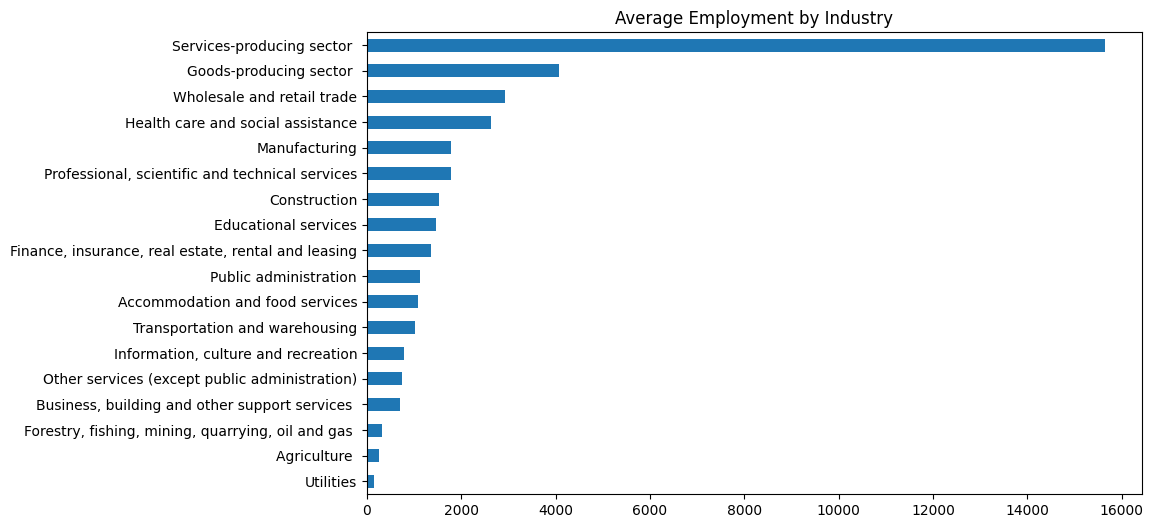

In [144]:
industry_avg = df.drop(columns=['Reference period']).mean()
industry_avg.sort_values().plot(kind='barh', figsize=(10,6), title='Average Employment by Industry')


 - **Insight**: Between 2019 and 2025, the Services-producing sector was the largest employer in Canada, with an average employment level of approximately 15.7 million people. The Goods-producing sector ranked second, employing around 4.0 million people, followed by Wholesale and Retail Trade with approximately 2.9 million employees. This highlights the dominant role of service-based industries in the Canadian labour market, accounting for the majority of employment opportunities during the study period.

### **Employment Trends**

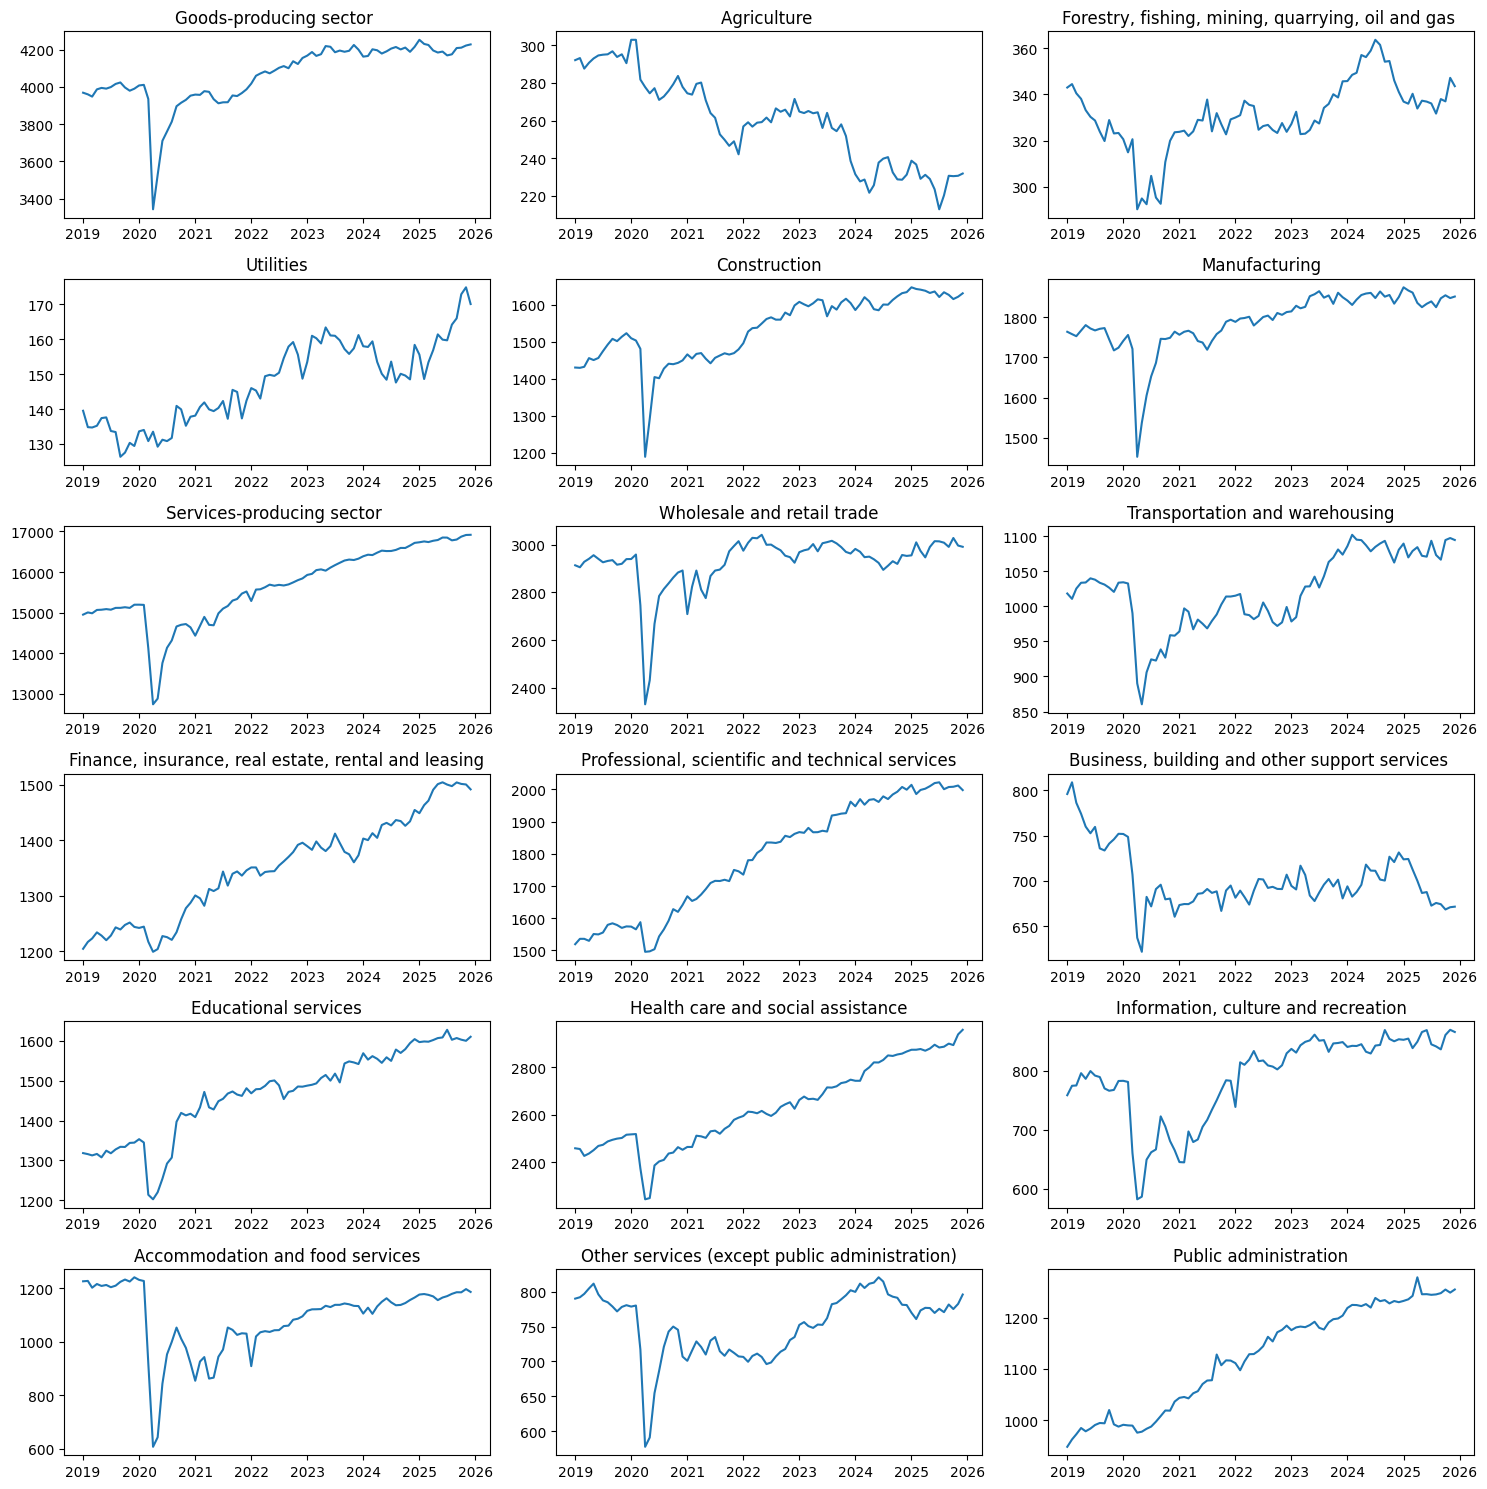

In [145]:
fig, axes = plt.subplots(
    nrows=6,
    ncols=3,
    figsize=(15,15)
)

axes = axes.flatten()

for i, col in enumerate(df.columns[1:]):
    axes[i].plot(df['Reference period'], df[col])
    axes[i].set_title(col)

plt.tight_layout()  

- **Insight**: The employment trends reveal a significant disruption across nearly all industries during the early stages of the COVID-19 pandemic in 2020, followed by a gradual recovery in subsequent years. Service-oriented industries such as Accommodation and Food Services, Information, Culture and Recreation, and Wholesale and Retail Trade experienced the sharpest declines, reflecting the impact of lockdowns and reduced consumer activity.

    By contrast, sectors such as Health Care and Social Assistance, Professional, Scientific and Technical Services, and Public Administration demonstrated strong and sustained employment growth throughout the recovery period. Most industries had recovered to or exceeded their pre-pandemic employment levels by 2025, indicating a resilient Canadian labour market.

    Notably, Health Care and Social Assistance and Professional, Scientific and Technical Services showed the strongest long-term upward trends, while Agriculture and Business, Building and Other Support Services exhibited relatively weaker growth and greater fluctuations over time.

## **3. COVID-19 Impact Analysis**

### **Pre-COVID Employment among Industries**

<Axes: title={'center': 'Average Employment by Industry (2019)'}>

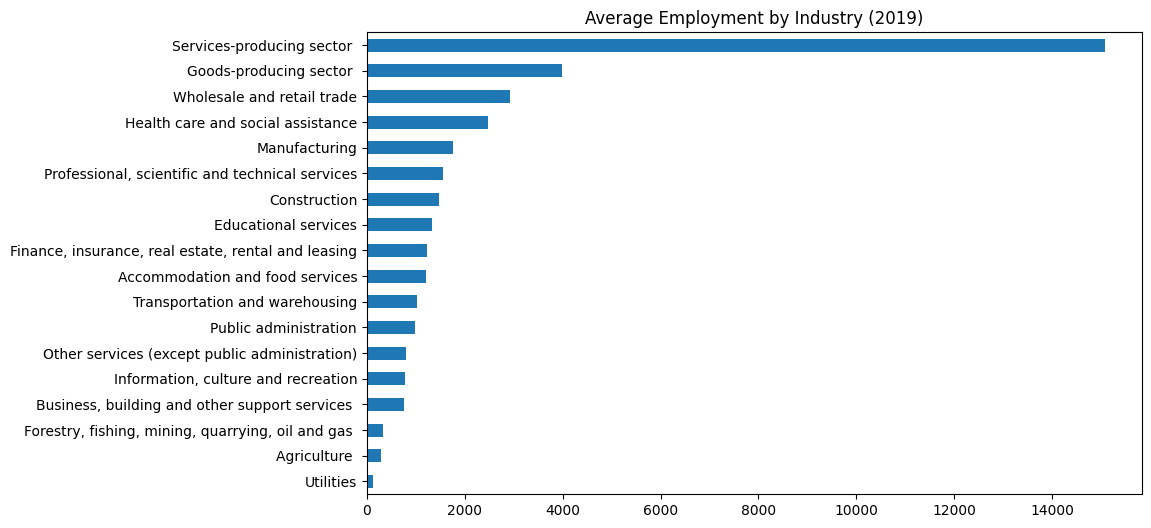

In [146]:
industry_avg_2019 = df[df['Reference period'].dt.year == 2019].drop(columns=['Reference period']).mean()
industry_avg_2019.sort_values().plot(kind='barh', figsize=(10,6), title='Average Employment by Industry (2019)')

- **Insight**: Prior to COVID-19, employment was concentrated in service-oriented industries. Wholesale and Retail Trade, Health Care and Social Assistance, and Manufacturing were the largest employers, while Utilities, Agriculture, and Natural Resources accounted for relatively small shares of total employment. This distribution serves as a baseline for assessing the pandemic's impact on Canada's labour market.

### **Job Loss**

In [147]:
covid_impact =df.iloc[15] - df.iloc[12]
display(covid_impact)

Reference period                                       91 days 00:00:00
Goods-producing sector                                           -664.7
Agriculture                                                       -25.1
Forestry, fishing, mining, quarrying, oil and gas                 -30.4
Utilities                                                          -0.1
Construction                                                     -320.2
Manufacturing                                                    -288.8
Services-producing sector                                       -2454.2
Wholesale and retail trade                                       -610.4
Transportation and warehousing                                   -144.0
Finance, insurance, real estate, rental and leasing               -43.0
Professional, scientific and technical services                   -78.3
Business, building and other support services                    -114.5
Educational services                                            

<Axes: title={'center': 'Covid Impact on Employment by Industry'}>

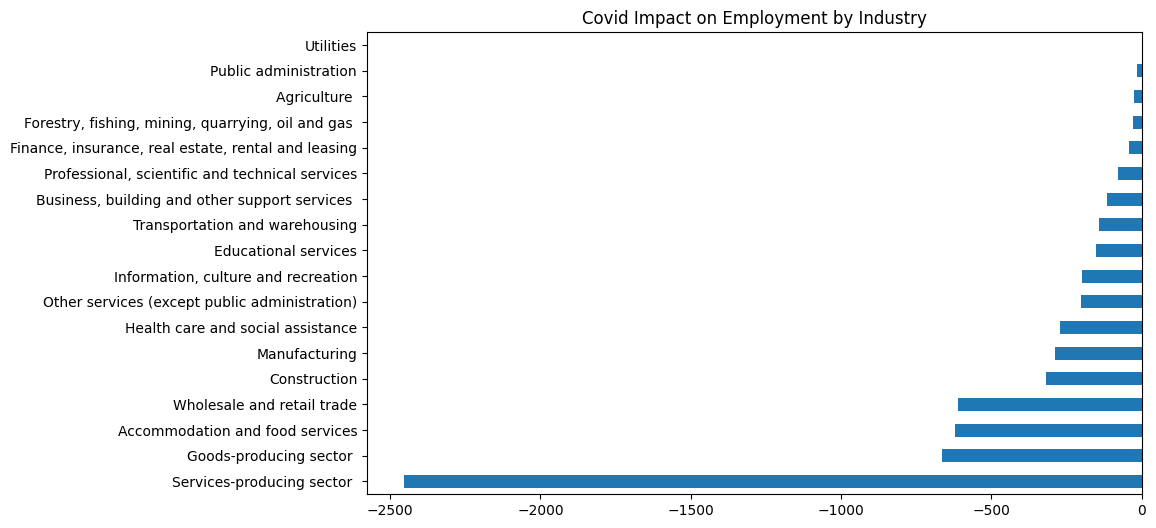

In [148]:
covid_impact.drop('Reference period').sort_values().plot(kind='barh', figsize=(10,6), title='Covid Impact on Employment by Industry')


- **Insight**: The onset of COVID-19 caused substantial employment losses across most Canadian industries between January and April 2020. Service-related industries were the hardest hit, with Accommodation and Food Services and Wholesale and Retail Trade experiencing the largest declines. Meanwhile, Utilities, Public Administration, and Agriculture showed relatively limited employment reductions, suggesting greater resilience to the economic shock.


### **Recovery**

In [149]:
industry_avg_2020 = df[df['Reference period'].dt.year == 2020].drop(columns=['Reference period']).mean()
industry_avg_2025 = df[df['Reference period'].dt.year == 2025].drop(columns=['Reference period']).mean()
growth_rate = (industry_avg_2025 - industry_avg_2020) / industry_avg_2020 * 100
display(growth_rate)


Goods-producing sector                                 10.233073
Agriculture                                           -18.723354
Forestry, fishing, mining, quarrying, oil and gas      10.175524
Utilities                                              20.825563
Construction                                           15.331665
Manufacturing                                           9.954655
Services-producing sector                              17.952804
Wholesale and retail trade                              8.376341
Transportation and warehousing                         14.461156
Finance, insurance, real estate, rental and leasing    20.466859
Professional, scientific and technical services        27.988583
Business, building and other support services           0.494634
Educational services                                   21.682280
Health care and social assistance                      20.143288
Information, culture and recreation                    25.759194
Accommodation and food se

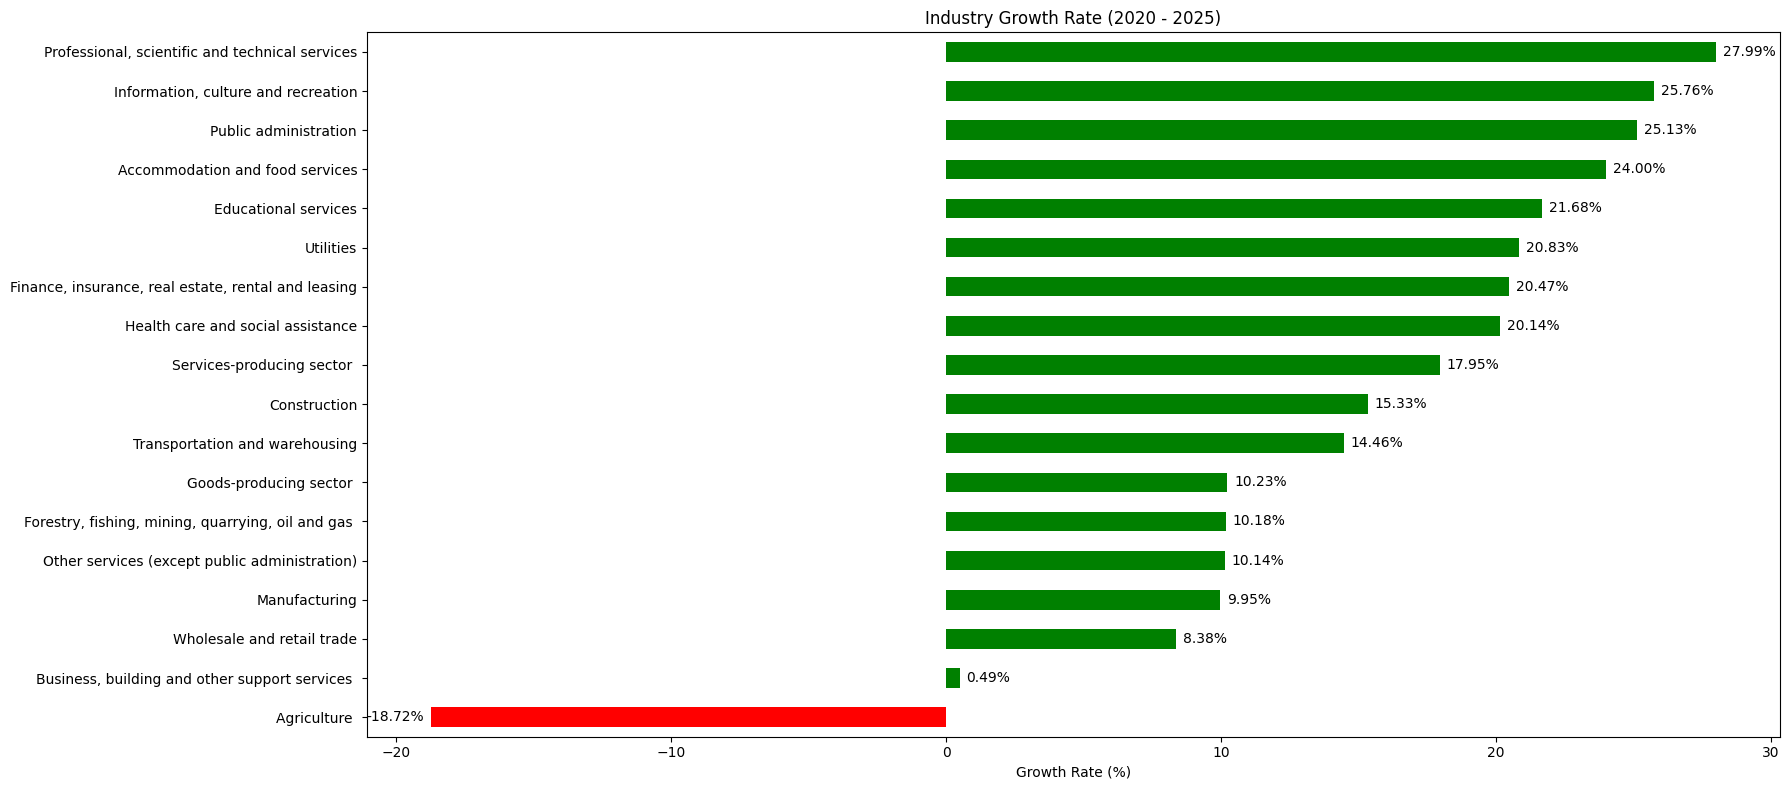

In [150]:
sorted_growth = growth_rate.sort_values()
colors = ['green' if v >= 0 else 'red' for v in sorted_growth]

fig, ax = plt.subplots(figsize=(18,8))
sorted_growth.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Growth Rate (%)')
ax.set_title('Industry Growth Rate (2020 - 2025)')


for p in ax.patches:
    x = p.get_width()
    y = p.get_y() + p.get_height() / 2
    ha = 'left' if x >= 0 else 'right'
    offset = 0.25 if x >= 0 else -0.25
    ax.text(x + offset, y, f'{x:.2f}%', va='center', ha=ha, fontsize=10)

plt.tight_layout()
plt.show()

- **Insight**: Between 2020 and 2025, most Canadian industries experienced a strong recovery in employment following the initial COVID-19 shock. Professional, Scientific and Technical Services recorded the strongest growth (+28%), followed by Information, Culture and Recreation (+26%) and Public Administration (+25%). Notably, Accommodation and Food Services, one of the industries most severely impacted during the pandemic, rebounded significantly with employment growth of approximately 24%. In contrast, Agriculture was the only industry to experience a sustained decline, with employment decreasing by nearly 19% over the period. Overall, the results suggest that Canada's labour market recovered successfully, although the pace of recovery varied considerably across industries.

## **4. Conclusion**

After performing exploratory data analysis on Canadian employment data from **2019 to 2025**, several key findings emerge regarding the impact of COVID-19 and the subsequent labour market recovery.

* Prior to the pandemic, employment was heavily concentrated in service-oriented industries, with **Wholesale and Retail Trade**, **Health Care and Social Assistance**, and **Manufacturing** representing the largest employers.
* The onset of COVID-19 in early 2020 caused significant employment losses across nearly all industries. **Accommodation and Food Services**, **Wholesale and Retail Trade**, and **Construction** experienced the most severe declines, highlighting their vulnerability to lockdown measures and reduced economic activity.
* Despite the initial shock, most industries demonstrated strong recovery between 2020 and 2025. **Professional, Scientific and Technical Services**, **Information, Culture and Recreation**, and **Public Administration** recorded the highest employment growth rates.
* **Accommodation and Food Services**, one of the hardest-hit sectors during the pandemic, showed a substantial rebound, indicating the resilience of consumer-facing industries.
* In contrast, **Agriculture** was the only industry that experienced a sustained decline over the study period, suggesting industry-specific challenges beyond the pandemic.
* Overall, the Canadian labour market proved highly resilient, with most industries recovering to or even surpassing their pre-pandemic employment levels by 2025.

This analysis demonstrates how economic shocks can affect industries differently and highlights the importance of examining sector-level employment trends when evaluating labour market performance and recovery.

